# CoLA Advection

In this notebook related to artificial data generation, we are going to advect the actomyosin cortex based on a velocity field. 

1. [Generating Actomyosin Cortices](./artificial_cells.ipynb) was used to generate synthetic microscopy data of actomyosin cortices.
2. [Generating CoLA Cuts](./artificial_cola.ipynb) was used to introduce a quasi-random cut to simulate where CoLA could happen in real data.
3. [Generating Velocity Fields](./cola_velocity_field.ipynb) was used to generate a synthetic velocity field basedon the cut.

We are now going to integrate these three. While conceptually easy, the concept of **advection** lies at the heart of this notebook.

In [1]:
import matplotlib as mpl
import numpy as np

from IPython.display import HTML
from tqdm import tqdm

# Increase the embed size limit
mpl.rcParams['animation.embed_limit'] = 400_000_000  # 400 MB

Make sure to run `pip install -e .` before running the cell below. This command will make sure `diet4cola` is installed as a module in your current Python/Conda environment.

In [2]:
from diet4cola.advection import advect_backward_sim
from diet4cola.cut import CoLACut
from diet4cola.mask import mask_on_condition
from diet4cola.operations import blur, directional_gradients, mul, invert
from diet4cola.velocity import compute_velocity_fields, prior_exp
from diet4cola.sdf import sdf_box, sdf_box_vectorized, compute_rounded_sdfs

from diet4cola.utils import *

## Synthetic Actomyosin Cortex

**! Disclaimer &mdash; Uncommend animations if you wish to view them, they take quite some time to load for longer simulations (i.e. smaller timesteps)**

As we have done many times before, we create (or in this particular case load) a synthetic actomyosin cortex and introduce an synthetic CoLA cut.

In [3]:
# Cell parameters
seed = 42
width = 512
height = 512

np.random.seed(seed)
off_x = 256 + (np.random.randint(32) - 16)
off_y = 256 + (np.random.randint(32) - 16)

In [4]:
actomyosin_layer = load_cortex('./data/cortex_1.npy')

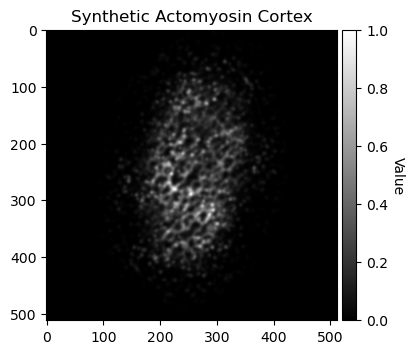

In [5]:
plot_2d_array(actomyosin_layer, 'Synthetic Actomyosin Cortex')

In [6]:
cola_cut = CoLACut((off_x, off_y), 32, 150, seed)

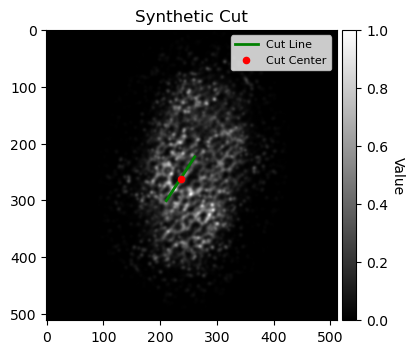

In [7]:
plot_synthetic_cut(actomyosin_layer, 
                   cola_cut.cut_center, 
                   cola_cut.cut_origin,
                   cola_cut.cut_destination)

## Velocity Field

In the [previous notebook](./cola_velocity_field.ipynb) we created a velocity field. From physics, we know that velocity determines how a point moves in space over time. Imagine the velocity $\bold{v}(\bold{r}, t)$ of $\bold{r} = (x, y)$ can be split into the velocities for each component of $\bold{r}$.

* $v_x(\bold{r}, t)$ gives the displacement in the direction of the $x$-axis.
* $v_y(\bold{r}, t)$ gives the displacement in the direction of the $y$-axis.

Let's start by recreating the velocity field from earlier. We will tweak the timescale after we are done, since the current velocity field gives a pretty accurate intuition.

In [8]:
t_min = 0
t_max = 20

# From t_min, t_max, iterations, compute step
time_step = 0.5

# Create time points
timepoints = np.arange(t_min, t_max + time_step, time_step)
iterations = len(timepoints)

normalized_timepoints = timepoints / t_max

Let's set the actual parameters for the SDF and velocity field. After this, we simply generate the SDF and velocity field over time.

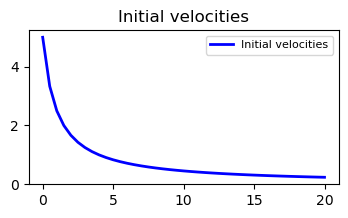

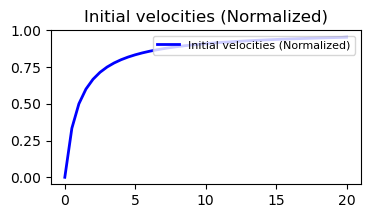

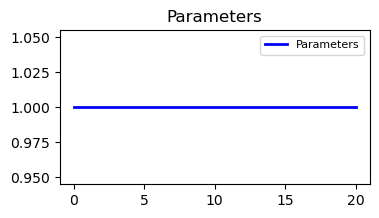

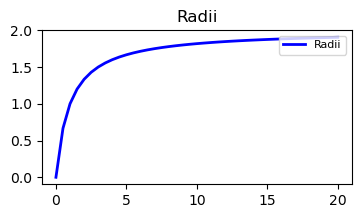

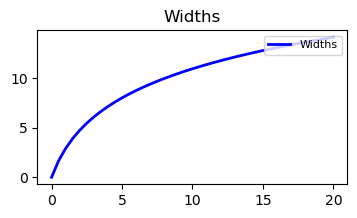

In [9]:
k = 5
parameter = 1
radius = 2
alpha = 5
max_falloff_distance = 100

def exponential_initial(alpha, t, k):
    return alpha * np.exp(-t * k)

def hyperbolic_initial(alpha, t, k):
    return (alpha ** 2) * (1.0 / (k * t + alpha))

initial_velocities = np.array([hyperbolic_initial(alpha, t, k) for t in timepoints])
inverted_initial_velocities_norm = invert(initial_velocities / alpha)
parameters = np.array([parameter] * iterations)

radii = [radius] * iterations
widths = [0] * iterations

# Create proper radii/widths
for i in range(iterations):
    if i == 0:
        radii[i] = 0
        widths[i] = 0
        continue

    radii[i] = inverted_initial_velocities_norm[i] * radius
    widths[i] = widths[i - 1] + time_step * initial_velocities[i]

plot_curve(initial_velocities, timepoints, 'Initial velocities')
plot_curve(inverted_initial_velocities_norm, timepoints, 'Initial velocities (Normalized)')
plot_curve(parameters, timepoints, 'Parameters')
plot_curve(radii, timepoints, 'Radii')
plot_curve(widths, timepoints, 'Widths')

In [10]:
sdf_fields = compute_rounded_sdfs(512, 512, cola_cut.cut_origin, cola_cut.cut_destination, widths, radii, False, sdf_box, iterations)

In [11]:
sdf_animation = animate_2d_data(sdf_fields, None, None, 100, 'RdBu_r', 'SDF (over Time)')

In [12]:
'''
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

html_anim = HTML(sdf_animation.to_jshtml())
plt.close(sdf_animation._fig)  # <-- closes the figure so the static plot doesn't show
html_anim
'''

'\nplt.rcParams["animation.html"] = "jshtml"\nplt.ioff()\n\nhtml_anim = HTML(sdf_animation.to_jshtml())\nplt.close(sdf_animation._fig)  # <-- closes the figure so the static plot doesn\'t show\nhtml_anim\n'

In [13]:
masked_sdf_fields = np.array([mask_on_condition(sdf < 0, 0, 1) for sdf in sdf_fields])
clipped_rounded_sdf_fields = np.array([mask_on_condition(sdf < 0, 0, sdf) for sdf in sdf_fields])

In [14]:
masked_sdf_anim = animate_2d_data(masked_sdf_fields, None, None, 100, 'gray', 'SDF Mask (over Time)')
clipped_sdf_anim = animate_2d_data(clipped_rounded_sdf_fields, None, None, 100, 'RdBu_r', 'Clipped SDF (over Time)')

In [15]:
'''
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

html_anim = HTML(masked_sdf_anim.to_jshtml())
plt.close(masked_sdf_anim._fig)  # <-- closes the figure so the static plot doesn't show
html_anim
'''

'\nplt.rcParams["animation.html"] = "jshtml"\nplt.ioff()\n\nhtml_anim = HTML(masked_sdf_anim.to_jshtml())\nplt.close(masked_sdf_anim._fig)  # <-- closes the figure so the static plot doesn\'t show\nhtml_anim\n'

In [16]:
'''
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

html_anim = HTML(clipped_sdf_anim.to_jshtml())
plt.close(clipped_sdf_anim._fig)  # <-- closes the figure so the static plot doesn't show
html_anim
'''

'\nplt.rcParams["animation.html"] = "jshtml"\nplt.ioff()\n\nhtml_anim = HTML(clipped_sdf_anim.to_jshtml())\nplt.close(clipped_sdf_anim._fig)  # <-- closes the figure so the static plot doesn\'t show\nhtml_anim\n'

In [17]:
velocity_fields = compute_velocity_fields(clipped_rounded_sdf_fields, prior_exp, timepoints, initial_velocities, max_falloff_distance, iterations)
masked_velocity_fields = np.array([vf * msdf for (vf, msdf) in zip(velocity_fields, masked_sdf_fields)])

print(velocity_fields.shape)

100%|██████████| 41/41 [00:13<00:00,  2.96it/s]

(41, 512, 512)


We finally overlay the first velocity field with values of zero except those that are exactly on the cut to prevent the whole cortex from artificially expanding.

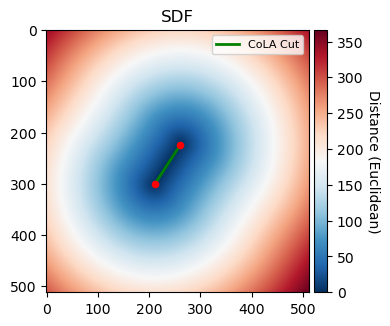

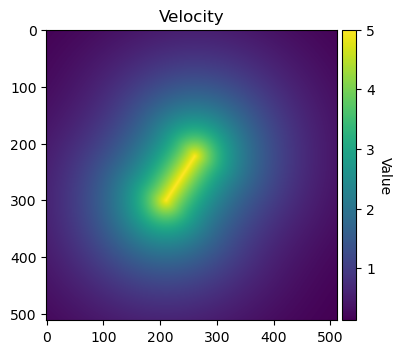

In [18]:
plot_sdf(clipped_rounded_sdf_fields[0, :, :], cola_cut.cut_origin, cola_cut.cut_destination)
plot_2d_array(velocity_fields[0, :, :], 'Velocity', 'viridis',  min=np.min(velocity_fields[0, :, :]), max=np.max(velocity_fields[0, :, :]))

In [19]:
velocity_fields[0, :, :] = np.where(clipped_rounded_sdf_fields[0, :, :] < 1, velocity_fields[0, :, :], 0)
masked_velocity_fields[0, :, :] = np.where(clipped_rounded_sdf_fields[0, :, :] < 1, masked_velocity_fields[0, :, :], 0)

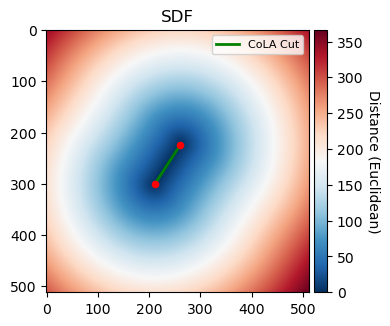

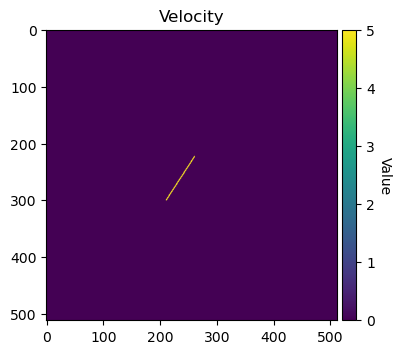

In [20]:
plot_sdf(clipped_rounded_sdf_fields[0, :, :], cola_cut.cut_origin, cola_cut.cut_destination)
plot_2d_array(velocity_fields[0, :, :], 'Velocity', 'viridis',  min=np.min(velocity_fields[0, :, :]), max=np.max(velocity_fields[0, :, :]))

## Backward Advection

Before diving into the code necessary for backward advection, let's go over what backward advection actually is. In computational fluid dynamics, **advection** refers to the transport of a quantity (in this case, the 'density' of the actomyosin cortex) by the flow of a velocity field. 

If we denote

* $\phi(\bold{r}, t)$ as a scalar quantity (e.g. density)
* $\bold{v}(\bold{r}, t)$ as the velocity field (as explained earlier)

then advection is governed by 

$$ \frac{\partial \phi}{\partial t} + \bold{v} \cdot \nabla \phi = 0 $$

This means that the value of $\phi$ attached to each "fluid" parcel remains constant as it moves &mdash; it's simply *carried* by the flow without being created or destroyed. The quantity $\phi$ is **conserved along the flow**.

In **forward advection**, we compute how the quantity moves *with* the velocity. However, this causes significant numerical instabilities since we are trying to predict the future values from the current ones.

**Backward advection** (i.e. a semi-Lagrangian method) instead traces backward along the velocity field to find *where a fluid parcel came from*. This method is stable, even for large time steps and is thus ideal for our use case.

### Idea behind Backward Advection

To compute $\phi^{n+1}(\bold{r})$, instead of moving the quantity forward, we ask ourselves:

> "Where was the fluid particle currently at $\bold{r}$ located at the previous time step?"

Mathematically speaking;

$$ \bold{r}_{\text{prev}} = \bold{r} - \Delta t \bold{v}(\bold{r})$$

Then we sample $\phi^n(\bold{r}_{\text{prev}})$, &mdash; usually via interpolation since $\bold{r}_{\text{prev}}$ isn't perfectly located on a grid point &mdash; and assign that value to the current cell:

$$ \phi^{n+1}(\bold{r}) = \phi^n(\bold{r}_{\text{prev}})$$

This is the core of the **semi-Lagrangian advection schema**, which we will now be implementing on our 2D grid.

### 2D Numerical Derivation

Let's unpack how this works numerically in our situation. We are given

* A 2D scalar field, the *actomyosin cortex* which we will denote $\phi_{\text{amc}}$.
* A 2D velocity field which was synthetically generated which we will call $\bold{v}$ where $\bold{v}(\bold{r}) = (v_x(\bold{r}), v_y(\bold{r}))$
* A timestep given by the variable `step`, which in the following derivation will be denoted $dt$ for brevity.

For each grid cell $(i, j)$:

1. Compute the **backtraced position**:

$$ 
\begin{cases}
    x_{\text{prev}} = i - dt \cdot v_x(i, j)\\
    y_{\text{prev}} = j - dt \cdot v_y(i, j)
\end{cases}
$$

2. Use **bilinear interpolation** to find $\phi(x_{\text{prev}}, y_{\text{prev}})$:
    * Find the integer grid coordinates surrounding $(x_{\text{prev}}, y_{\text{prev}})$. This simply is the floor/ceil of $x_{\text{prev}}$, $y_{\text{prev}}$.
    * Interpolate between those four neighbouring grid values.

3. Store the interpolated value in the new field

4. **!** Handle boundary conditions properly &mdash; since in our case, in theory, the actomyosin cortex can move "outside" of the image frame, we can simply discard the update rule (i.e. mass **CAN** leave our bounds!)

## Backward Advection on Synthetic CoLA Cut

This is really where the magic happens! We will use the velocity field to perform backward advection on the actomyosin cortex. Let's visualize the velocity field over time once more.

In [21]:
vf_animation = animate_2d_data(velocity_fields, None, None, 100, 'viridis', 'Velocity (unmasked) over Time')
vfm_animation = animate_2d_data(masked_velocity_fields, None, None, 100, 'viridis', 'Velocity (masked) over Time')

In [22]:
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

html_anim = HTML(vf_animation.to_jshtml())
plt.close(vf_animation._fig)  # <-- closes the figure so the static plot doesn't show
html_anim

In [23]:

plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

html_anim = HTML(vfm_animation.to_jshtml())
plt.close(vfm_animation._fig)  # <-- closes the figure so the static plot doesn't show
html_anim

In [24]:
from matplotlib.animation import FFMpegWriter

# Optional: configure ffmpeg writer
writer = FFMpegWriter(fps=10, metadata=dict(artist='Matthias Kovacic'), bitrate=1800)

# Save the animation as an mp4
vf_animation.save("./video/synthetic_velocity_animation.mp4", writer=writer)

# Close the figure if you don't want it displayed
plt.close(vf_animation._fig)

Let's quickly visualize what all these gradients are doing over time, so that we get a better idea of what we are actually trying to do.

### Velocity Gradients

In [25]:
velocity_gradients = directional_gradients(velocity_fields)
velocity_dxs = velocity_gradients[:, 0, :, :] * -1 # Reverse gradient to go outward
velocity_dys = velocity_gradients[:, 1, :, :] * -1 # Reverse gradient to go outward

velocity_grad_magnitudes = np.sqrt(velocity_dxs ** 2 + velocity_dys ** 2)

In [26]:
'''
vel_dx_animation = animate_2d_data(velocity_dxs, None, None, 100, 'RdBu_r', 'Velocity dX (over Time)')
vel_dy_animation = animate_2d_data(velocity_dys, None, None, 100, 'RdBu_r', 'Velocity dY (over Time)')
vel_grad_animation = animate_2d_data(velocity_grad_magnitudes, None, None, 100, 'RdBu_r', 'Velocity Gradient Magnitude (over Time)')
'''

"\nvel_dx_animation = animate_2d_data(velocity_dxs, None, None, 100, 'RdBu_r', 'Velocity dX (over Time)')\nvel_dy_animation = animate_2d_data(velocity_dys, None, None, 100, 'RdBu_r', 'Velocity dY (over Time)')\nvel_grad_animation = animate_2d_data(velocity_grad_magnitudes, None, None, 100, 'RdBu_r', 'Velocity Gradient Magnitude (over Time)')\n"

In [27]:
'''
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

html_anim = HTML(vel_dx_animation.to_jshtml())
plt.close(vel_dx_animation._fig)  # <-- closes the figure so the static plot doesn't show
html_anim
'''

'\nplt.rcParams["animation.html"] = "jshtml"\nplt.ioff()\n\nhtml_anim = HTML(vel_dx_animation.to_jshtml())\nplt.close(vel_dx_animation._fig)  # <-- closes the figure so the static plot doesn\'t show\nhtml_anim\n'

In [28]:
'''
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

html_anim = HTML(vel_dy_animation.to_jshtml())
plt.close(vel_dy_animation._fig)  # <-- closes the figure so the static plot doesn't show
html_anim
'''

'\nplt.rcParams["animation.html"] = "jshtml"\nplt.ioff()\n\nhtml_anim = HTML(vel_dy_animation.to_jshtml())\nplt.close(vel_dy_animation._fig)  # <-- closes the figure so the static plot doesn\'t show\nhtml_anim\n'

In [29]:
'''
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

html_anim = HTML(vel_grad_animation.to_jshtml())
plt.close(vel_grad_animation._fig)  # <-- closes the figure so the static plot doesn't show
html_anim
'''

'\nplt.rcParams["animation.html"] = "jshtml"\nplt.ioff()\n\nhtml_anim = HTML(vel_grad_animation.to_jshtml())\nplt.close(vel_grad_animation._fig)  # <-- closes the figure so the static plot doesn\'t show\nhtml_anim\n'

### SDF Gradients

In [30]:
sdf_gradients = directional_gradients(clipped_rounded_sdf_fields)

sdf_dys = sdf_gradients[:, 0, :, :]
sdf_dxs = sdf_gradients[:, 1, :, :]

sdf_gradient_magnitudes = np.sqrt(sdf_dxs ** 2 + sdf_dys ** 2)

In [31]:
'''
sdf_dx_animation = animate_2d_data(sdf_dxs, None, None, 100, 'RdBu_r', 'SDF dX (over Time)')
sdf_dy_animation = animate_2d_data(sdf_dys, None, None, 100, 'RdBu_r', 'SDF dY (over Time)')
sdf_grad_animation = animate_2d_data(sdf_gradient_magnitudes, None, None, 100, 'RdBu_r', 'SDF Gradient Magnitude (over Time)')
'''

"\nsdf_dx_animation = animate_2d_data(sdf_dxs, None, None, 100, 'RdBu_r', 'SDF dX (over Time)')\nsdf_dy_animation = animate_2d_data(sdf_dys, None, None, 100, 'RdBu_r', 'SDF dY (over Time)')\nsdf_grad_animation = animate_2d_data(sdf_gradient_magnitudes, None, None, 100, 'RdBu_r', 'SDF Gradient Magnitude (over Time)')\n"

In [32]:
'''
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

html_anim = HTML(sdf_dx_animation.to_jshtml())
plt.close(sdf_dx_animation._fig)  # <-- closes the figure so the static plot doesn't show
html_anim
'''

'\nplt.rcParams["animation.html"] = "jshtml"\nplt.ioff()\n\nhtml_anim = HTML(sdf_dx_animation.to_jshtml())\nplt.close(sdf_dx_animation._fig)  # <-- closes the figure so the static plot doesn\'t show\nhtml_anim\n'

In [33]:
'''
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

html_anim = HTML(sdf_dy_animation.to_jshtml())
plt.close(sdf_dy_animation._fig)  # <-- closes the figure so the static plot doesn't show
html_anim
'''

'\nplt.rcParams["animation.html"] = "jshtml"\nplt.ioff()\n\nhtml_anim = HTML(sdf_dy_animation.to_jshtml())\nplt.close(sdf_dy_animation._fig)  # <-- closes the figure so the static plot doesn\'t show\nhtml_anim\n'

In [34]:
'''
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

html_anim = HTML(sdf_grad_animation.to_jshtml())
plt.close(sdf_grad_animation._fig)  # <-- closes the figure so the static plot doesn't show
html_anim
'''

'\nplt.rcParams["animation.html"] = "jshtml"\nplt.ioff()\n\nhtml_anim = HTML(sdf_grad_animation.to_jshtml())\nplt.close(sdf_grad_animation._fig)  # <-- closes the figure so the static plot doesn\'t show\nhtml_anim\n'

Let's quickly visualize some gradient maps of the SDF over time, since we will be using it to advect the actomyosin cortex over time.

In [35]:
'''
animate_gradient_field(sdf_dxs, sdf_dys, 16, False, 100, 'viridis', 'SDF Gradient')
'''

"\nanimate_gradient_field(sdf_dxs, sdf_dys, 16, False, 100, 'viridis', 'SDF Gradient')\n"

This is exactly the gradient field we need in order to move our points &mdash; over time, only points inside the SDF are not affected. Keep in mind that this gradient field only shows the **direction** at each time point. For the magnitude of movement, we use the velocity fields we have precomputed earlier. We can now put this all together in creating the advected actomyosin cortex.

### Actomyosin Cortex Advection

Now, because of how our advection works, we will first need to multiply the cortices with the masks generated earlier to get a clean empty space in the space of the cut. We will slightly blur the sdf masks however, since otherwise we get a quite unnatural result.

In [36]:
blurred_masked_sdf_fields = np.array([blur(sdf.astype(np.float64), (5, 5), 5) for sdf in masked_sdf_fields])

mask_animation = animate_2d_data(blurred_masked_sdf_fields, None, None, 100, 'gray', 'Blurred SDF Mask')

In [37]:
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

html_anim = HTML(mask_animation.to_jshtml())
plt.close(mask_animation._fig)  # <-- closes the figure so the static plot doesn't show
html_anim

We now perform backwards advection and multiply each advected cortex with a blurred SDF mask

In [38]:
advected_cortices = advect_backward_sim(actomyosin_layer, sdf_dxs, sdf_dys, masked_velocity_fields, iterations, time_step)

print(advected_cortices.shape)

# Multiply each advected cortex with the blurred SDF masks
advected_cortices = mul(advected_cortices, blurred_masked_sdf_fields)

100%|██████████| 40/40 [00:01<00:00, 37.18it/s]

(41, 512, 512)


Let's animate our final result!

In [39]:
cortex_animation = animate_2d_data(advected_cortices, None, None, 100, 'gray', 'Synthetic Actomyosin Example')

In [40]:
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

html_anim = HTML(cortex_animation.to_jshtml())
plt.close(cortex_animation._fig)  # <-- closes the figure so the static plot doesn't show
html_anim

In [41]:
# Optional: configure ffmpeg writer
writer = FFMpegWriter(fps=10, metadata=dict(artist='Matthias Kovacic'), bitrate=1800)

# Save the animation as an mp4
cortex_animation.save("./video/synthetic_cortex_animation.mp4", writer=writer)

# Close the figure if you don't want it displayed
plt.close(cortex_animation._fig)